## Model Validation

We will take a look at the confusion matrix, Precision and AUC curve in order to validate the model.

In [ ]:
# Predictions on the validation set
y_true = []
y_pred = []

# Collect true labels and predictions
for batch in val_gen:
    x_batch, y_batch = batch  # Unpack the batch
    x1_batch, x2_batch = x_batch  # Unpack the input pairs (x1 and x2)
    
    # Ensure x1_batch and x2_batch have the correct shape
    if len(x1_batch.shape) == 3:  # Add channel dimension if missing
        x1_batch = x1_batch[..., np.newaxis]
    if len(x2_batch.shape) == 3:  # Add channel dimension if missing
        x2_batch = x2_batch[..., np.newaxis]
    
    predictions = model.predict([x1_batch, x2_batch])
    y_true.extend(y_batch)
    y_pred.extend(predictions)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Convert predicted probabilities to class labels (assuming binary classification with a threshold of 0.5)
y_pred_labels = np.where(y_pred > 0.5, 1, 0)


1/1 [==============================] - 0s 59ms/step


Let's plot that.

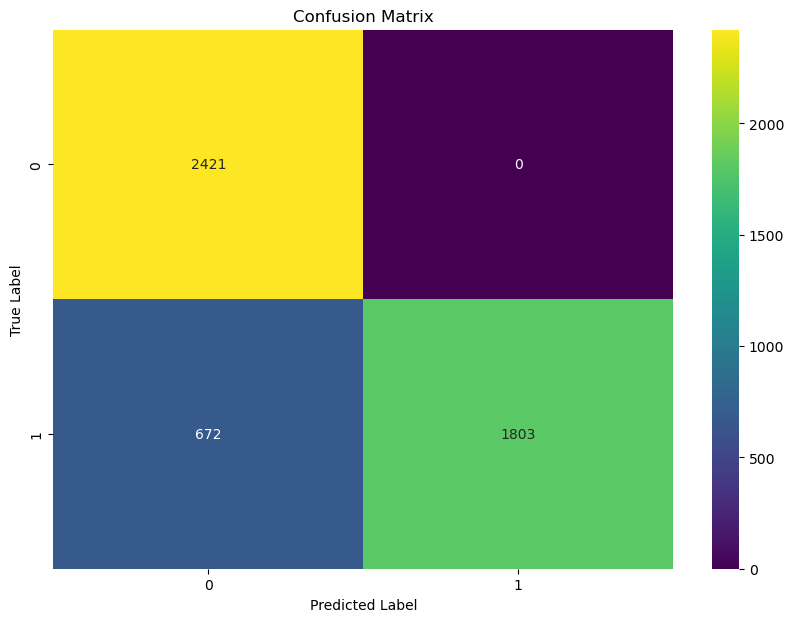

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.88      2421
         1.0       1.00      0.73      0.84      2475

    accuracy                           0.86      4896
   macro avg       0.89      0.86      0.86      4896
weighted avg       0.89      0.86      0.86      4896



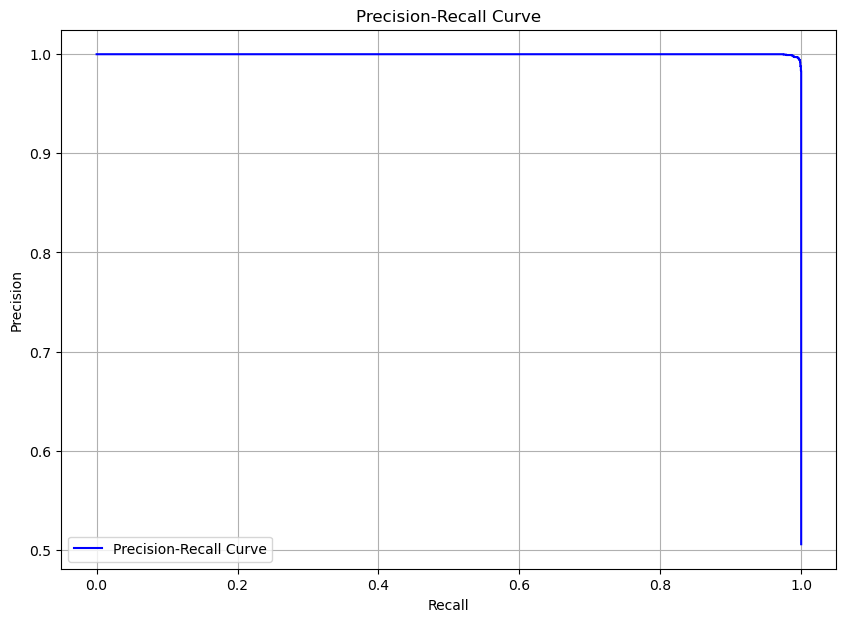

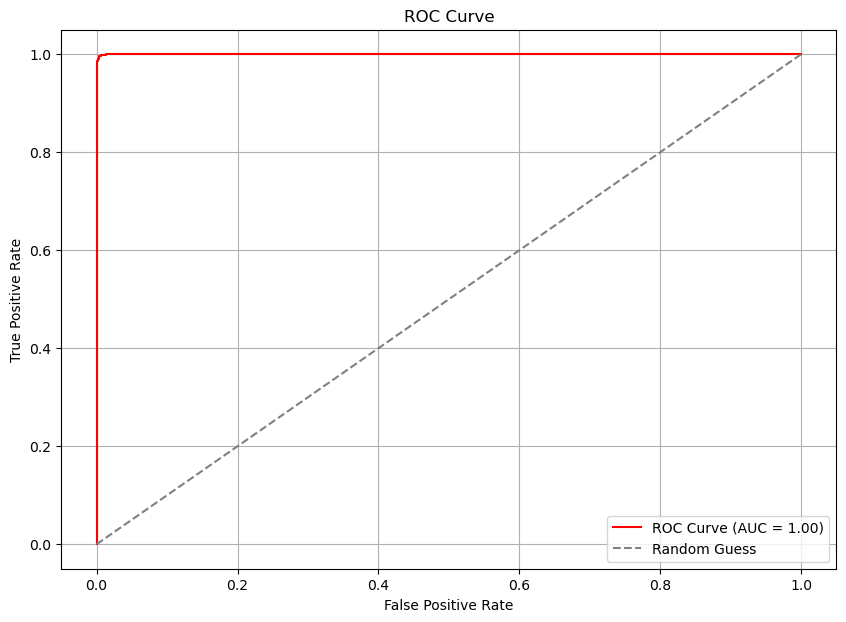

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)

# Alternatively, use seaborn to create a more informative heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print a classification report for more detailed metrics
print(classification_report(y_true, y_pred_labels))

# Compute Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_pred)

# Compute ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, color='b', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Plot ROC Curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='r', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Model Validation Summary

The fingerprint recognition model was trained and validated using the SOCOFing dataset, augmented with deformations such as obliteration, central rotation, and z-cut. These augmented images were compared against their original counterparts to assess the model’s robustness. The goal of this approach is to simulate real-world scenarios where fingerprints might be damaged or distorted, ensuring the model performs reliably under such conditions.

**Confusion Matrix Analysis:**

**Precision:** Indicates the proportion of predicted positives that are correct:

	•	0.78 for class 0.0 (non-matching fingerprint).
	•	1.00 for class 1.0 (matching fingerprint).
High precision for 1.0 ensures minimal false positives, which is crucial for security applications.

**Recall:** Reflects the proportion of actual positives identified:

	•	1.00 for class 0.0.
	•	0.73 for class 1.0.
Lower recall for 1.0 indicates that some matching fingerprints are not being identified.

**F1-Score:** The harmonic mean of precision and recall:

	•	0.88 for class 0.0.
	•	0.84 for class 1.0.
Overall Accuracy: 86% across 4896 samples.

**Precision-Recall Curve:**

The precision-recall curve demonstrates that precision remains high across most recall values. This is a positive indicator for the model’s ability to maintain precision even as recall increases, minimizing false positives in critical scenarios.

**ROC Curve:**

The receiver operating characteristic (ROC) curve shows a perfect area under the curve (AUC) of 1.00, indicating near-perfect separability between matching (1.0) and non-matching (0.0) fingerprints.

**Importance of Avoiding False Positives:**

In security systems, false positives (incorrectly classifying a non-matching fingerprint as a match) can lead to severe breaches. The model’s perfect precision for class 1.0 ensures that false positives are entirely avoided in this evaluation. However, the lower recall for class 1.0 suggests some genuine matches might be missed, which could reduce user experience in certain applications.

**Suggestions for Model Improvement:**

	1.	Improve Recall for Matching Fingerprints (1.0):
		•	Use class-balanced loss functions such as Focal Loss to emphasize harder-to-classify cases.
		•	Apply cost-sensitive learning by penalizing false negatives more than false positives.
		•	Conduct active learning to focus on difficult-to-classify examples during training.
	2.	Enhance Augmentation Techniques:
		•	Introduce more diverse deformations, such as blurring, smudging, and extreme rotation, to better simulate adversarial conditions.
		•	Use adversarial data augmentation to train the model against synthetic “hard examples” generated by adversarial algorithms.
	3.	Feature Engineering:
		•	Leverage additional fingerprint-specific features (e.g., minutiae points, ridge counts) alongside CNN-based methods.
		•	Experiment with multi-modal learning, combining image features with auxiliary data (e.g., timestamp or context) for enhanced accuracy.
	4.	Post-Processing and Threshold Tuning:
		•	Adjust the decision threshold to balance precision and recall, depending on application requirements.
		•	Use probabilistic calibration (e.g., Platt Scaling) to fine-tune the model’s confidence scores.


## Conclusion

The model demonstrates strong potential for fingerprint recognition, achieving high precision and an AUC of 1.00. However, improvements in recall for matching fingerprints and robustness to further deformations could enhance its applicability in security-sensitive environments. By leveraging advanced training techniques, augmentation strategies, and architecture refinements, the model can achieve even higher reliability and robustness.